**TUGAS BESAR PENGANTAR AI**

<b>Topik: </b>
Klasifikasi National Health and Nutrition Health Survey 2013-2014 (NHANES) Age Prediction Subset menggunakan KNN Classification

<b>Kelompok: 12 </b>

Anggota:
1. Teuku Muhammad Ibrahim - 1301223159
2. Jason Jeremy B.B. - 1301223110
3. M. Hibban Musyaffa - 1301223177

**PENDAHULUAN**

Disini kami menggunakan dataset National Health and Nutrition Health Survey 2013-2014 (NHANES) Age Prediction Subset, Data ini mengandung berbagai fitur yang relevan dengan usia, seperti:

Pengukuran fisiologis: Tekanan darah, kolesterol, gula darah, massa tubuh, dll.

Pilihan gaya hidup: Aktivitas fisik

**Tugas ini bertujuan untuk:**

-Menyelidiki kemampuan KNN dalam memprediksi usia menggunakan dataset NHANES.

-Mengoptimalkan parameter KNN untuk mencapai akurasi prediksi tertinggi.

**Pengerjaan tugas ini dibagi menjadi 7 langkah sebagai berikut.**

1.Setup awal (import library dan dataset)

2.Visualisasi data (menampilan box plot)

3.Pre-processing data (scalling, kfold)

4.Klasifikasi (membuat algoritma KNN Classification dan modeling)

5.Tuning (melakukan Regresi dengan penambahan aturan)

6.Evaluasi

7.Kesimpulan

**1. SETUP AWAL**

Setup awal merupakan hal penting yang perlu dilakukan di awal-awal. Dataset dan tools untuk melatih data perlu disiapkan terlebih dahulu dengan cara import library dan dataset. Kemudian randomize data agar terbagi rata untuk setiap fold nanti. Selanjutnya mengassign bahwa variabel X sebagai features, dan variabel Y sebagai target, dan yang terakhir merubah bentuk klasifikasi menjadi numerik.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo, list_available_datasets
list_available_datasets()

-------------------------------------
The following datasets are available:
-------------------------------------
Dataset Name                                                                            ID    
------------                                                                            --    
Abalone                                                                                 1     
Adult                                                                                   2     
Annealing                                                                               3     
Audiology (Standardized)                                                                8     
Auto MPG                                                                                9     
Automobile                                                                              10    
Balance Scale                                                                           12    
Balloons                       

In [ ]:
Ageprediction_dataset = fetch_ucirepo('National Health and Nutrition Health Survey 2013-2014 (NHANES) Age Prediction Subset')

x = Ageprediction_dataset.data.features
y = Ageprediction_dataset.data.targets

In [ ]:
display(Ageprediction_dataset)

{'data': {'ids':          SEQN
  0     73564.0
  1     73568.0
  2     73576.0
  3     73577.0
  4     73580.0
  ...       ...
  2273  83711.0
  2274  83712.0
  2275  83713.0
  2276  83718.0
  2277  83727.0
  
  [2278 rows x 1 columns],
  'features':       RIAGENDR  PAQ605  BMXBMI  LBXGLU  DIQ010  LBXGLT  LBXIN
  0          2.0     2.0    35.7   110.0     2.0   150.0  14.91
  1          2.0     2.0    20.3    89.0     2.0    80.0   3.85
  2          1.0     2.0    23.2    89.0     2.0    68.0   6.14
  3          1.0     2.0    28.9   104.0     2.0    84.0  16.15
  4          2.0     1.0    35.9   103.0     2.0    81.0  10.92
  ...        ...     ...     ...     ...     ...     ...    ...
  2273       2.0     2.0    33.5   100.0     2.0    73.0   6.53
  2274       1.0     2.0    30.0    93.0     2.0   208.0  13.02
  2275       1.0     2.0    23.7   103.0     2.0   124.0  21.41
  2276       2.0     2.0    27.4    90.0     2.0   108.0   4.99
  2277       1.0     2.0    24.5   108.0     2.

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2278 entries, 0 to 2277
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   RIAGENDR  2278 non-null   float64
 1   PAQ605    2278 non-null   float64
 2   BMXBMI    2278 non-null   float64
 3   LBXGLU    2278 non-null   float64
 4   DIQ010    2278 non-null   float64
 5   LBXGLT    2278 non-null   float64
 6   LBXIN     2278 non-null   float64
dtypes: float64(7)
memory usage: 124.7 KB


In [ ]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2278 entries, 0 to 2277
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age_group  2278 non-null   object
dtypes: object(1)
memory usage: 17.9+ KB


In [ ]:
y['age_group'].unique()

array(['Adult', 'Senior'], dtype=object)

In [ ]:
label_name = y['age_group'].unique().tolist()
label_code = [int(i) for i in range(len(label_name))]
y['age_group'] = y['age_group'].map({name: code for name, code in zip(label_name,label_code)})

In [ ]:
y['age_group'].unique()

array([0, 1])

**2. VISUALISASI DATA**

Kami menggunakan visual boxplot sebagai metode visualisasi.

<Axes: >

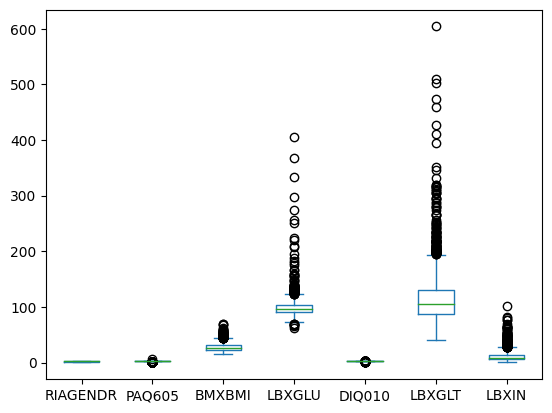

In [ ]:
x.plot(kind='box')

**3. PRE-PROCESSING DATA**


Pre-processing Data untuk Klasifikasi Usia Akurat dengan KNN
Sebelum membangun model klasifikasi usia dengan KNN, data perlu diolah agar siap untuk analisis klasifikasi. Dalam tugas ini, pre-processing data dilakukan dengan beberapa langkah:

1. Scaling: Data diskalakan menggunakan StandardScaler untuk menormalisasi fitur-fiturnya. Hal ini membantu memastikan bahwa semua fitur memiliki skala yang sama dan tidak terlalu menggeser hasil klasifikasi.

2. Visualisasi: Boxplot digunakan untuk memvisualisasi distribusi data setelah scaling. Hasilnya menunjukkan bahwa boxplot menjadi lebih mudah dibaca dan memiliki skala yang setara, menandakan bahwa data siap untuk klasifikasi.

3. Pemisahan Data: KFold digunakan untuk membagi dataset menjadi data training dan data validation. KFold membagi data menjadi 5 bagian (K=5), di mana 4 bagian digunakan untuk training dan 1 bagian digunakan untuk validasi. Hal ini membantu memastikan bahwa model klasifikasi dievaluasi dengan baik pada data yang tidak dilihat selama training.

**SCALING DAN VISUALISASI**

<Axes: >

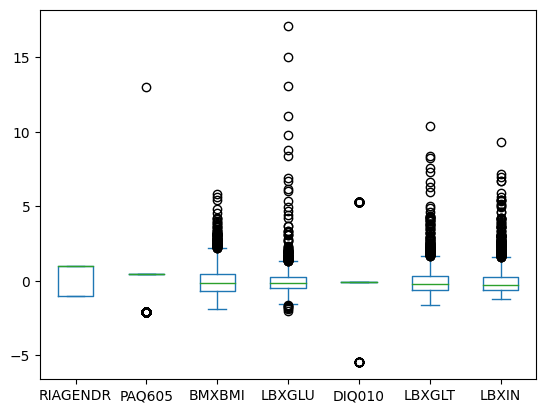

In [ ]:
# Standard scaler
((x - x.mean())/ x.std()).plot(kind='box')

**KFOLD PROCESSING: PEMISAHAN DATA**

In [ ]:
# MENGACAK DATA

x = x.sample(frac=1, random_state=42).reset_index(drop=True)
y = y.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
# MENENTUKAN INDEKS DATA UNTUK SPLIT

number_of_folds = 5 # parameter k fold
number_per_fold = len(x) // number_of_folds #menentukan banyak data setiap fold

fold_split_index = []
for i in range(number_of_folds):
  start_index = number_per_fold * i #Definisikan indeks awal data validasi fold ke-i
  end_index= start_index + number_per_fold # Definisikan indeks akhir data validasi fold ke-i
  val_index = np.arange(start_index, end_index) # definikasi indeks data validasi

  mask = ~np.isin(x.index, val_index)
  train_index = x.index[mask]
  fold_split_index.append((train_index, val_index))

In [ ]:
for train_index, val_index, in fold_split_index:
    print(f'val start index: {val_index.min()}')

val start index: 0
val start index: 455
val start index: 910
val start index: 1365
val start index: 1820


**METODE YANG DIGUNAKAN**

<p>kami disini menggunakan KNN Classification, metode nya adalah klasifikasi berdasarkan tetangga terdekat. Berikut adalah penjelasan detailnya:<p>

1. Menentukan Titik Data Baru:

Titik data baru yang ingin diklasifikasikan usianya disiapkan. Titik data ini dapat berupa data individu baru yang belum memiliki label usia.
2. Menghitung Jarak:

Algoritma KNN menghitung jarak antara titik data baru dengan semua titik data dalam dataset training. Jarak yang digunakan adalah Euclidean
3. Menentukan Tetangga Terdekat:

Algoritma KNN memilih k tetangga terdekat dari titik data baru berdasarkan jarak yang telah dihitung. Nilai k merupakan hyperparameter yang perlu dioptimalkan untuk mencapai performa model terbaik.
4. Klasifikasi Usia:

Label mayoritas dari k tetangga terdekat ditugaskan ke titik data baru. Artinya, jika mayoritas tetangga terdekat memiliki label usia tertentu, maka label usia tersebut juga diberikan kepada titik data baru.

**4. KLASIFIKASI**

In [ ]:
class KNNClassifier:
  def __init__(self, n_neighbors=5):
     self.n_neighbors = n_neighbors
     self.x_train = None
     self.y_train = None

  def fit(self, x, y):
    self.x_train = x
    self.y_train = y

  def predict(self,x):
    y_pred = [self._predict_one(x) for x in x]
    return np.array(y_pred)

  def _predict_one(self, x):
    distances = np.linalg.norm(self.x_train - x, axis=1)
    nearest_indices = distances.argsort()[:self.n_neighbors]
    nearest_labels = self.y_train[nearest_indices]
    # Ensure nearest_labels is a 1D array
    nearest_labels = np.array(nearest_labels).flatten()
    most_common = np.bincount(nearest_labels).argmax()
    return most_common


**5.EVALUASI (NEIGHBOUR = 5)**

Kami mengevaluasi ketepatannya menggunakan skor akurasi dan f1 score.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, classification_report

In [ ]:
print("EVALUASI PADA DATA TEST")

model = KNNClassifier(n_neighbors=8)

total_f1 = 0
total_akurasi = 0

for i, (train_index, val_index) in enumerate (fold_split_index):
    x_train_fold = x.iloc[train_index].reset_index(drop=True)
    y_train_fold = y.iloc[train_index].reset_index(drop=True)

    x_val_fold = x.iloc[val_index].reset_index(drop=True)
    y_val_fold = y.iloc[val_index].reset_index(drop=True)

    model.fit(x_train_fold.values, y_train_fold.values)
    y_pred = model.predict(x_val_fold.values)

    f1 = f1_score(y_val_fold, y_pred, average = "micro") * 100
    akurasi = accuracy_score(y_val_fold, y_pred)*100

    total_f1 += f1
    total_akurasi += akurasi
    print(f'Skor F1 fold ke - {i + 1}\f: {f1}%')
    print(f'Akurasi fold ke - {i + 1}\f: {akurasi}%')
    print()
print('\n Rata-rata F1', total_f1 / number_of_folds)
print('\n Rata-rata akurasi', total_akurasi / number_of_folds)

EVALUASI PADA DATA TEST
Skor F1 fold ke - 1: 83.2967032967033%
Akurasi fold ke - 1: 83.2967032967033%

Skor F1 fold ke - 2: 84.3956043956044%
Akurasi fold ke - 2: 84.3956043956044%

Skor F1 fold ke - 3: 85.49450549450549%
Akurasi fold ke - 3: 85.49450549450549%

Skor F1 fold ke - 4: 85.27472527472527%
Akurasi fold ke - 4: 85.27472527472527%

Skor F1 fold ke - 5: 81.97802197802197%
Akurasi fold ke - 5: 81.97802197802197%


 Rata-rata F1 84.08791208791209

 Rata-rata akurasi 84.08791208791209


In [ ]:
print("EVALUASI PADA DATA TRAIN")

model = KNNClassifier(n_neighbors=8)

total_f1 = 0
total_akurasi = 0

for i, (train_index, val_index) in enumerate (fold_split_index):
    x_train_fold = x.iloc[train_index].reset_index(drop=True)
    y_train_fold = y.iloc[train_index].reset_index(drop=True)

    x_val_fold = x.iloc[val_index].reset_index(drop=True)
    y_val_fold = y.iloc[val_index].reset_index(drop=True)

    model.fit(x_train_fold.values, y_train_fold.values)
    y_pred = model.predict(x_train_fold.values)

    f1 = f1_score(y_train_fold, y_pred, average = "micro") * 100
    akurasi = accuracy_score(y_train_fold, y_pred)*100

    total_f1 += f1
    total_akurasi += akurasi
    print(f'Skor F1 fold ke - {i + 1}\f: {f1}%')
    print(f'Akurasi fold ke - {i + 1}\f: {akurasi}%')
    print()
print('\n Rata-rata F1', total_f1 / number_of_folds)
print('\n Rata-rata akurasi', total_akurasi / number_of_folds)

EVALUASI PADA DATA TRAIN
Skor F1 fold ke - 1: 86.06692265496434%
Akurasi fold ke - 1: 86.06692265496434%

Skor F1 fold ke - 2: 85.35381239714755%
Akurasi fold ke - 2: 85.35381239714755%

Skor F1 fold ke - 3: 85.40866703236424%
Akurasi fold ke - 3: 85.40866703236424%

Skor F1 fold ke - 4: 85.35381239714755%
Akurasi fold ke - 4: 85.35381239714755%

Skor F1 fold ke - 5: 86.23148656061437%
Akurasi fold ke - 5: 86.23148656061437%


 Rata-rata F1 85.6829402084476

 Rata-rata akurasi 85.6829402084476


**6. HYPERPARAMETER TUNING**

Mencari kemungkinan akurasi tertinggi dengan cara mencoba dan merubah-rubah n_neighbour nya

In [ ]:
tuning_log_f1=[]
tuning_log_akurasi=[]

for i in range(1, 16):
    model = KNNClassifier(n_neighbors=i)

    total_f1 = 0
    total_akurasi = 0
    for i, (train_index, val_index) in enumerate (fold_split_index):
      x_train_fold = x.iloc[train_index].reset_index(drop=True)
      y_train_fold = y.iloc[train_index].reset_index(drop=True)

      x_val_fold = x.iloc[val_index].reset_index(drop=True)
      y_val_fold = y.iloc[val_index].reset_index(drop=True)

      model.fit(x_train_fold.values, y_train_fold.values)
      y_pred = model.predict(x_val_fold.values)

      f1 = f1_score(y_val_fold, y_pred, average = "micro") * 100
      akurasi = accuracy_score(y_val_fold, y_pred)*100

      total_f1 += f1
      total_akurasi += akurasi
    tuning_log_f1.append(total_f1 / number_of_folds)
    tuning_log_akurasi.append(total_akurasi / number_of_folds)

Text(0, 0.5, 'peforma dalam %')

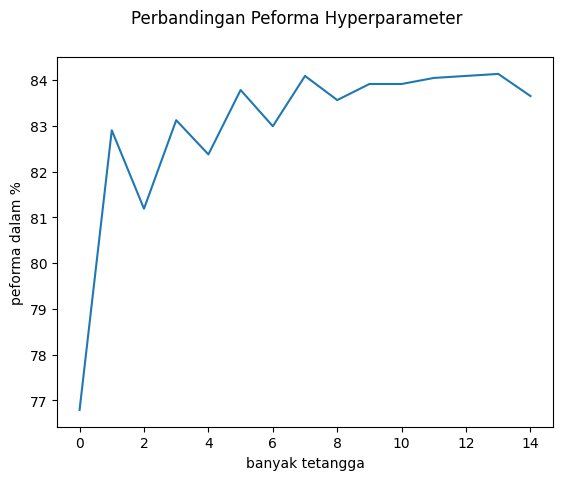

In [ ]:
import matplotlib.pyplot as plt

plt.subplot(111)
plt.suptitle('Perbandingan Peforma Hyperparameter')
plt.plot(tuning_log_f1)
plt.xlabel('banyak tetangga')
plt.ylabel('peforma dalam %')

Text(0, 0.5, 'peforma dalam %')

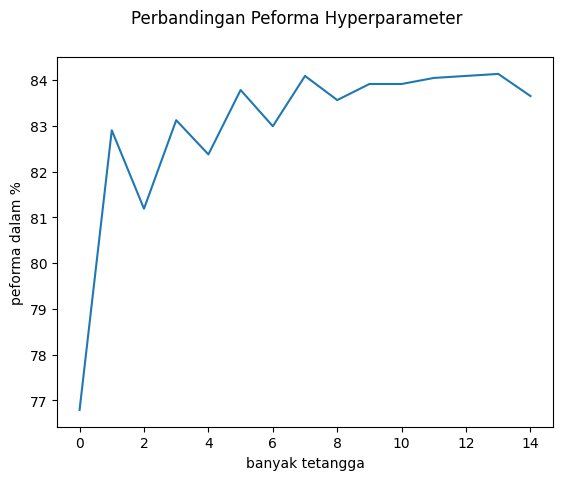

In [ ]:
import matplotlib.pyplot as plt

plt.subplot(111)
plt.suptitle('Perbandingan Peforma Hyperparameter')
plt.plot(tuning_log_akurasi)
plt.xlabel('banyak tetangga')
plt.ylabel('peforma dalam %')

**7. Kesimpulan**

Tugas ini meneliti penggunaan metode K-Nearest Neighbors (KNN) untuk membangun model prediksi usia yang akurat menggunakan dataset National Health and Nutrition Health Survey 2013-2014 (NHANES) Age Prediction Subset. Hasil menunjukkan bahwa KNN dapat memprediksi usia dengan akurasi dan f1 score yang tinggi, mencapai 82% dengan neighbor 5 (default) dan 84% dengan neighbor 8, data ini didapat dari hyperparameter tuning. Temuan ini menunjukkan potensi KNN untuk prediksi usia yang akurat dan membuka jalan bagi penelitian selanjutnya untuk mengembangkan model yang lebih canggih dan akurat.